   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

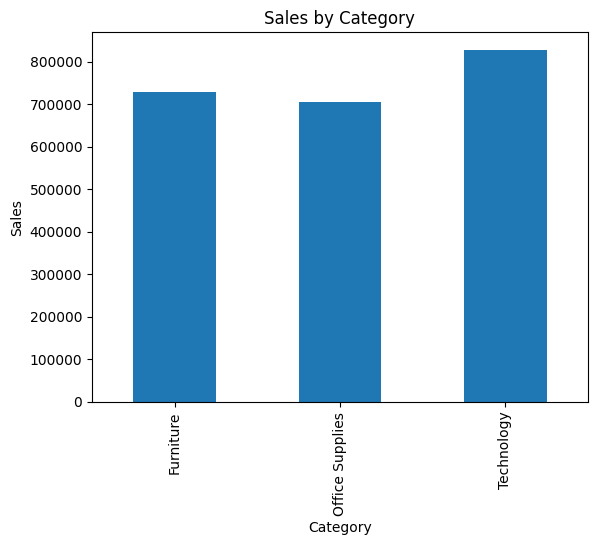

Month
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


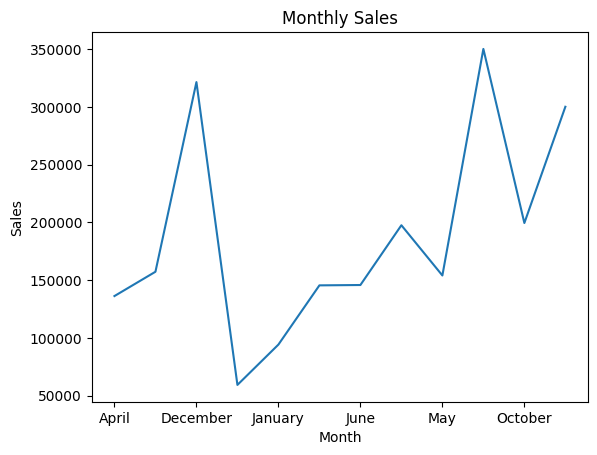

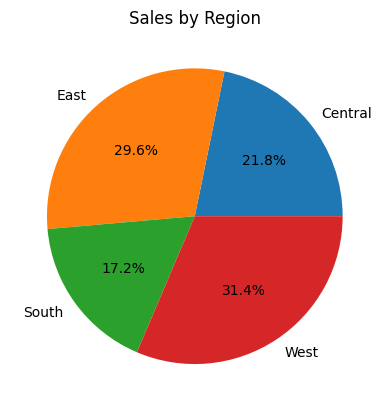

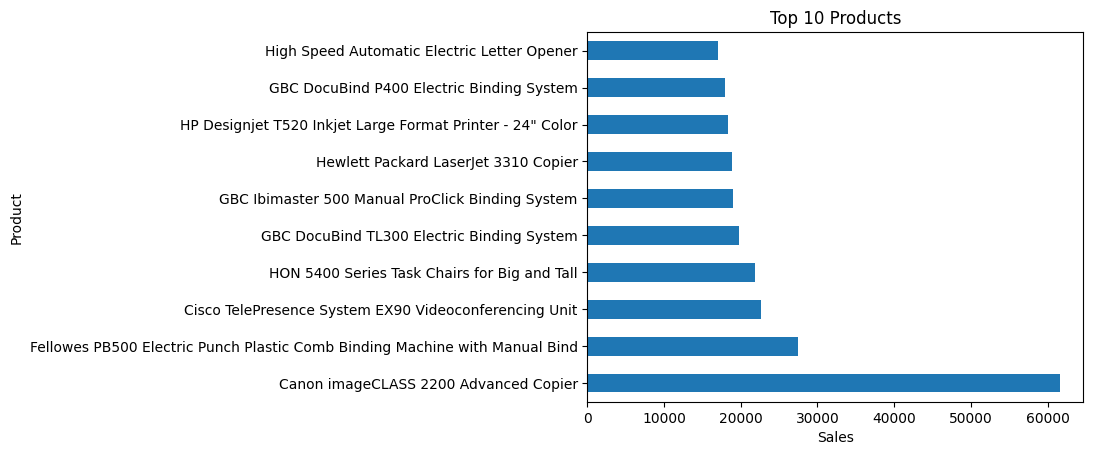

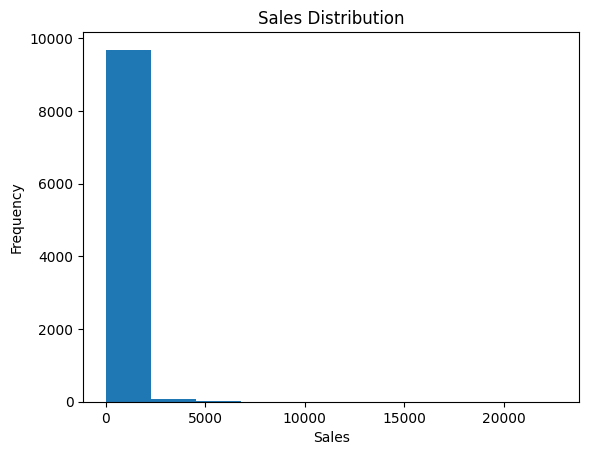

   Row ID        Order ID           Order Date            Ship Date  \
0       1  CA-2017-152156  2017-11-08 00:00:00  2017-11-11 00:00:00   
1       2  CA-2017-152156  2017-11-08 00:00:00  2017-11-11 00:00:00   
2       3  CA-2017-138688  2017-06-12 00:00:00  2017-06-16 00:00:00   
3       4  US-2016-108966  2016-10-11 00:00:00  2016-10-18 00:00:00   
4       5  US-2016-108966  2016-10-11 00:00:00  2016-10-18 00:00:00   

        Ship Mode Customer ID    Customer Name    Segment        Country  \
0    Second Class    CG-12520      Claire Gute   Consumer  United States   
1    Second Class    CG-12520      Claire Gute   Consumer  United States   
2    Second Class    DV-13045  Darrin Van Huff  Corporate  United States   
3  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States   
4  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States   

              City       State  Postal Code Region       Product ID  \
0        Henderson    Kentucky      42420.0  

In [ ]:
import pandas as pd
df=pd.read_csv("archive.csv")
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
print(df.info())
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)
average_sales = df["Sales"].mean()
print("Average Sales:", average_sales)
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)
product_sales = df.groupby("Product Name")["Sales"].sum()
top_products = product_sales.sort_values(ascending=False).head(10)
print(top_products)
customer_sales = df.groupby("Customer Name")["Sales"].sum()
top_customers = customer_sales.sort_values(ascending=False).head(10)
print(top_customers)
df["Month"] = df["Order Date"].dt.month_name()
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)
state_sales = df.groupby("State")["Sales"].sum()
print(state_sales.sort_values(ascending=False).head(10))
segment_sales = df.groupby("Segment")["Sales"].sum()
print(segment_sales)
city_sales = df.groupby("City")["Sales"].sum()
top_cities = city_sales.sort_values(ascending=False).head(10)
print(top_cities)
import matplotlib.pyplot as plt
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()
df["Month"] = df["Order Date"].dt.month_name()
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)
monthly_sales.plot(kind="line")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
region_sales = df.groupby("Region")["Sales"].sum()
region_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Region")
plt.ylabel("")
plt.show()
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="barh")
plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()
plt.hist(df["Sales"])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()
import sqlite3
conn = sqlite3.connect("sales.db")
df.to_sql("Sales", conn, if_exists="replace", index=False)
query = "SELECT * FROM Sales LIMIT 5"
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT SUM(Sales) AS Total_Sales
FROM Sales;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT Category,
SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY Category;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT Region,
SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY Region;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT
    `Product Name`,
    SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY `Product Name`
ORDER BY Total_Sales DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT
    `Customer Name`,
    SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY `Customer Name`
ORDER BY Total_Sales DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print(result)
conn.close()

In [5]:
import sqlite3
conn = sqlite3.connect("sales.db")
df.to_sql("Sales", conn, if_exists="replace", index=False)
query = "SELECT * FROM Sales LIMIT 5"
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT SUM(Sales) AS Total_Sales
FROM Sales;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT Category,
SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY Category;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT Region,
SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY Region;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT
    `Product Name`,
    SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY `Product Name`
ORDER BY Total_Sales DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print(result)
query = """
SELECT
    `Customer Name`,
    SUM(Sales) AS Total_Sales
FROM Sales
GROUP BY `Customer Name`
ORDER BY Total_Sales DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print(result)
conn.close()

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat